In [1]:
import pandas as pd 
import numpy as np
import matplotlib as plt

In [2]:
first_chunk = True
output_path = '../../../data/raw/humanbase/kidney_top_filtered.csv'

for chunk in pd.read_csv('../../../data/raw/humanbase/kidney_top', sep='\t', header=None, names=['entrez_a', 'entrez_b', 'posterior'], chunksize=1_000_000):
    filtered = chunk[chunk['posterior'] >= 0.2]
    
    if first_chunk:
        filtered.to_csv(output_path, index=False, mode='w', header=True)
        first_chunk = False
    else:
        filtered.to_csv(output_path, index=False, mode='a', header=False)

In [3]:
df = pd.read_csv(output_path)
df.head()

,entrez_a,entrez_b,posterior
0,100,10095,0.265728
1,100,10112,0.200844
2,100,10123,0.228643
3,100,10238,0.248867
4,100,10544,0.228126


In [4]:
df.shape

(853171, 3)

In [5]:
df.describe()

,entrez_a,entrez_b,posterior
count,8.531710e+05,8.531710e+05,853171.000000
mean,2.206731e+05,2.739537e+04,0.287012
std,4.413215e+06,2.908418e+05,0.098231
min,2.000000e+00,2.000000e+00,0.200002
25%,3.913000e+03,5.710000e+03,0.220544
50%,1.028000e+04,8.572000e+03,0.252790
75%,2.588600e+04,5.109600e+04,0.316412
max,1.005074e+08,1.002879e+08,0.992379


<Axes: >

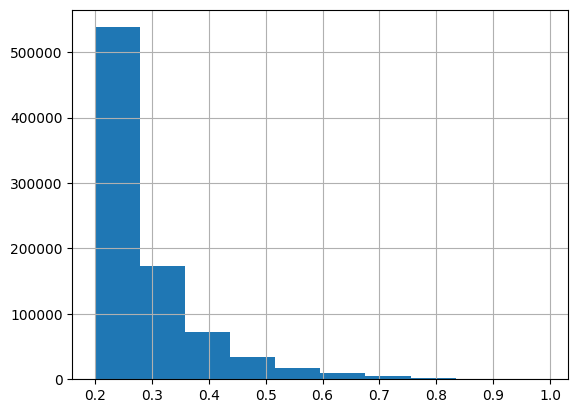

In [6]:
df['posterior'].hist()

In [7]:
gene = pd.read_csv("../../../data/kidney/labels.csv",nrows=0)
gene

,ModelID,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3


In [8]:
crispr_gene = pd.read_csv("../../../data/raw/depmap/CRISPRGeneEffect.csv",nrows=0)
crispr_gene

,Unnamed: 0,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),...,ZWILCH (55055),ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009)


In [9]:
crispr_gene.rename(columns={'Unnamed: 0':'ModelID'},inplace=True)
crispr_gene

,ModelID,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),...,ZWILCH (55055),ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009)


In [10]:
crispr_cols = crispr_gene.columns[1:] 
gene_cols = gene.columns[1:]  


In [11]:
crispr_symbols = crispr_cols.str.split(" (", regex=False).str[0]


In [12]:
entrez = crispr_cols[crispr_symbols.isin(gene_cols)]
entrez

Index(['A1BG (1)', 'A1CF (29974)', 'A2M (2)', 'A2ML1 (144568)',
       'A3GALT2 (127550)', 'A4GALT (53947)', 'A4GNT (51146)', 'AAAS (8086)',
       'AACS (65985)', 'AADAC (13)',
       ...
       'ZWILCH (55055)', 'ZWINT (11130)', 'ZXDA (7789)', 'ZXDB (158586)',
       'ZXDC (79364)', 'ZYG11A (440590)', 'ZYG11B (79699)', 'ZYX (7791)',
       'ZZEF1 (23140)', 'ZZZ3 (26009)'],
      dtype='str', length=17863)

In [13]:
entrez.str.split(" (", regex=False).str[1].str.rstrip(")")

Index(['1', '29974', '2', '144568', '127550', '53947', '51146', '8086',
       '65985', '13',
       ...
       '55055', '11130', '7789', '158586', '79364', '440590', '79699', '7791',
       '23140', '26009'],
      dtype='str', length=17863)

In [14]:
entrez_ids = entrez.str.split(" (", regex=False).str[1].str.rstrip(")").astype(int)
symbols = entrez.str.split(" (", regex=False).str[0]

entrez_to_symbol = dict(zip(entrez_ids, symbols))


In [15]:
symbols = entrez.str.split(" (", regex=False).str[0]
entrez_to_symbol = dict(zip(entrez_ids, symbols))


In [16]:
entrez_to_symbol[7428]


'VHL'

In [17]:
df['symbol_a'] = df['entrez_a'].map(entrez_to_symbol)
df['symbol_b'] = df['entrez_b'].map(entrez_to_symbol)


In [18]:
print(df['symbol_a'].isna().sum())
print(df['symbol_b'].isna().sum())


9262
7179


In [19]:
df_mapped = df.dropna(subset=['symbol_a', 'symbol_b'])
print(df_mapped.shape)


(837099, 5)


In [20]:
df_mapped = df_mapped[['symbol_a', 'symbol_b', 'posterior']]


In [21]:
print(df_mapped.shape)
print(df_mapped.isna().sum())


(837099, 3)
symbol_a     0
symbol_b     0
posterior    0
dtype: int64


In [22]:
df_mapped.to_csv('../../../data/kidney/humanbase_edges.csv', index=False)


In [23]:
print((df_mapped['symbol_a'] == df_mapped['symbol_b']).sum())


0


In [24]:
temp = pd.DataFrame(np.sort(df_mapped[['symbol_a','symbol_b']].values, axis=1))
print(temp.duplicated().sum())


0


In [25]:
df_mapped['posterior'].describe()


count    837099.000000
mean          0.287321
std           0.098219
min           0.200002
25%           0.220733
50%           0.253170
75%           0.316979
max           0.992379
Name: posterior, dtype: float64

<Axes: >

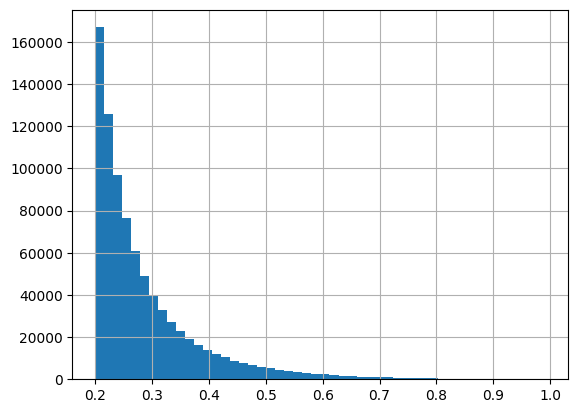

In [26]:
df_mapped['posterior'].hist(bins=50)


In [27]:
expression = pd.read_csv("../../../data/kidney/expression.csv")

In [28]:
missing = set(df_mapped['symbol_a']).union(df_mapped['symbol_b']) - set(expression.columns)
print(len(missing))


0
